In [1]:
import pandas as pd
import string
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Cargar los datos con la codificación correcta
df = pd.read_csv('data/spam.csv', encoding='latin-1')

df = df[['v1', 'v2']] 

df.columns = ['label', 'text']

print("Dataset cargado con éxito:")


# --- Parte A: Configuración de columnas ---
# Asegúrate de que estos nombres coincidan con los de tu DataFrame.
# Si tu columna de etiquetas se llama 'v1', cambia 'label' por 'v1'.
col_etiqueta = 'label'
col_texto = 'text'

# --- Parte B: Convertir etiquetas a números ---
# Lógica: Los modelos no entienden "ham" o "spam". Solo números.
# Creamos una nueva columna 'target' donde 'ham' será 0 y 'spam' será 1.
print("Paso 1: Convirtiendo etiquetas a números (0 y 1)...")
df['target'] = df[col_etiqueta].map({'ham': 0, 'spam': 1})


# --- Parte C: Limpieza de texto ---
# Lógica: Los signos de puntuación (¡, ?, ., ,) no suelen aportar significado
# para detectar spam. Son "ruido". Esta función los elimina para que el
# modelo se centre solo en las palabras importantes.
def limpiar_puntuacion(texto):
    # Revisa si el valor es texto antes de intentar limpiarlo
    if isinstance(texto, str):
        # str.translate es una forma súper eficiente de quitar caracteres
        return texto.translate(str.maketrans('', '', string.punctuation))
    return texto

print("Paso 2: Limpiando el texto de los mensajes...")
df['texto_limpio'] = df[col_texto].apply(limpiar_puntuacion)


# --- Parte D: Preparación de datos para el entrenamiento ---
# Lógica: No podemos usar todos nuestros datos para "enseñar" al modelo.
# Sería como darle a un estudiante el examen y las respuestas a la vez.
# No sabríamos si aprendió o solo memorizó.
# Por eso, separamos los datos: 80% para entrenar (aprender) y 20% para probar (el examen final).
X = df['texto_limpio']  # Los mensajes limpios (las "preguntas")
y = df['target']        # Las etiquetas 0 o 1 (las "respuestas")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Paso 3: Separando datos para entrenamiento (80%) y prueba (20%)...")


# --- Parte E: Crear la "Línea de Ensamblaje" y Entrenar ---
# Lógica: Aquí creamos un "Pipeline" o línea de ensamblaje. Esto es genial
# porque empaqueta dos pasos en uno:
# 1. 'vectorizer': Convierte las palabras de los SMS en números que el modelo entiende.
# 2. 'classifier': El modelo Naive Bayes que aprende a diferenciar entre 0 y 1.
# Al unirlos, nos aseguramos de que cualquiera que use nuestro modelo guardado
# no se olvide de hacer la limpieza y vectorización exactamente igual.
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

print("Paso 4: Entrenando el modelo... ¡Esto puede tardar un momento!")
# El método .fit() es, literalmente, "aprender" de los datos de entrenamiento.
pipeline.fit(X_train, y_train)


# --- Parte F: Guardar el modelo entrenado ---
# Lógica: El entrenamiento puede ser lento. No queremos repetirlo cada vez.
# Así que guardamos nuestro pipeline (que ya está "entrenado") en un archivo.
# La próxima vez, solo cargaremos este archivo y estará listo para usarse.
nombre_archivo = 'spam_detector.joblib'
joblib.dump(pipeline, nombre_archivo)

print(f"¡Éxito! Modelo guardado en el archivo: '{nombre_archivo}'")


# --- Parte G (Opcional): Verificación rápida ---
# Lógica: Usemos el 20% de datos que guardamos para el "examen final".
# Hacemos predicciones y las comparamos con las respuestas correctas.
predicciones = pipeline.predict(X_test)
print(f"\nPrecisión del modelo en el set de prueba: {accuracy_score(y_test, predicciones):.2%}")

Dataset cargado con éxito:
Paso 1: Convirtiendo etiquetas a números (0 y 1)...
Paso 2: Limpiando el texto de los mensajes...
Paso 3: Separando datos para entrenamiento (80%) y prueba (20%)...
Paso 4: Entrenando el modelo... ¡Esto puede tardar un momento!
¡Éxito! Modelo guardado en el archivo: 'spam_detector.joblib'

Precisión del modelo en el set de prueba: 97.76%


In [4]:
import joblib
import string

# --- Parte A: Cargar el modelo guardado ---
# Lógica: Estamos "abriendo el tupper" que guardamos antes.
# joblib.load() lee el archivo y reconstruye nuestro pipeline entrenado,
# dejándolo listo para usar.
nombre_archivo = 'spam_detector.joblib'
print(f"Cargando el modelo desde '{nombre_archivo}'...")
modelo_cargado = joblib.load(nombre_archivo)
print("¡Modelo cargado con éxito!")


# --- Parte B: Recrear la función de limpieza ---
# Lógica: ¡Esto es MUY importante! El modelo aprendió a partir de texto
# al que le quitamos la puntuación. Por lo tanto, para que pueda entender
# un mensaje nuevo, debemos aplicarle EXACTAMENTE la misma limpieza.
def limpiar_puntuacion(texto):
    if isinstance(texto, str):
        return texto.translate(str.maketrans('', '', string.punctuation))
    return texto


# --- Parte C: Probar con nuevos mensajes ---
# Lógica: Vamos a escribir un par de mensajes de prueba. Uno que claramente
# parece spam y otro que es un mensaje normal (ham).
mensajes_de_prueba = [
    "Congratulations! You've won a free trip to Cancun. Call now on 999-888-777 to claim your prize.", # Spam obvio
    "Hey, how about we meet at 7 for dinner? Let me know.", # Ham obvio
    "URGENT: Your bank account has been compromised. Click here to verify your identity http://bit.ly/fake-link" # Spam con link
]

# ... (el resto del código de la celda se queda exactamente igual) ...

# ¡No te olvides de limpiar los nuevos mensajes!
mensajes_limpios = [limpiar_puntuacion(m) for m in mensajes_de_prueba]

# --- Parte D: Realizar las predicciones ---
predicciones = modelo_cargado.predict(mensajes_limpios)
probabilidades = modelo_cargado.predict_proba(mensajes_limpios)

# --- Parte E: Interpretar los resultados ---
mapa_etiquetas = {0: 'SEGURO (Ham)', 1: 'SPAM'}

for i, mensaje in enumerate(mensajes_de_prueba):
    etiqueta_predicha = mapa_etiquetas[predicciones[i]]
    confianza_spam = probabilidades[i][1]

    print("\n-------------------------------------------")
    print(f"Mensaje: '{mensaje}'")
    print(f"Predicción: {etiqueta_predicha}")
    print(f"Confianza de que es SPAM: {confianza_spam:.2%}")

# =====================================


Cargando el modelo desde 'spam_detector.joblib'...
¡Modelo cargado con éxito!

-------------------------------------------
Mensaje: 'Congratulations! You've won a free trip to Cancun. Call now on 999-888-777 to claim your prize.'
Predicción: SPAM
Confianza de que es SPAM: 100.00%

-------------------------------------------
Mensaje: 'Hey, how about we meet at 7 for dinner? Let me know.'
Predicción: SEGURO (Ham)
Confianza de que es SPAM: 0.00%

-------------------------------------------
Mensaje: 'URGENT: Your bank account has been compromised. Click here to verify your identity http://bit.ly/fake-link'
Predicción: SPAM
Confianza de que es SPAM: 99.91%


In [6]:
# Asumo que tu DataFrame se sigue llamando 'df' y el modelo cargado 'modelo_cargado'.
# Si no es así, ajusta los nombres.

print("--- DIAGNÓSTICO DEL DATAFRAME 'df' ---")

# 1. Chequeo de balance de clases
# Lógica: Vamos a ver la proporción de mensajes seguros vs. spam.
# Si hay un 85% de 'ham' (0), el modelo puede tener la tentación de predecir siempre 0.
if 'target' in df.columns:
    print("\n[INFO 1] Balance de clases en la columna 'target':")
    print(df['target'].value_counts(normalize=True))
else:
    print("\n[ERROR 1] La columna 'target' no fue encontrada en el DataFrame.")


# 2. Chequeo de las primeras filas
# Lógica: Quiero ver si la limpieza y el mapeo a 0/1 se hicieron bien.
# Un error común es que si la columna original no era 'ham'/'spam', la columna 'target'
# se llena de valores nulos (NaN), lo que rompe el entrenamiento.
print("\n[INFO 2] Primeras 10 filas del DataFrame procesado:")
print(df.head(10))


# 3. Chequeo del vocabulario del modelo
# Lógica: Vamos a preguntarle al modelo cuántas palabras únicas aprendió.
# Si su "diccionario" es muy pequeño, es posible que no conozca palabras clave como "premio" o "gratis".
try:
    vocabulario = modelo_cargado.named_steps['vectorizer'].get_feature_names_out()
    print(f"\n[INFO 3] El modelo aprendió un vocabulario de {len(vocabulario)} palabras.")

    # Vamos a ver si conoce palabras clave de spam
    palabras_spam_comunes = ['premio', 'gratis', 'gana', 'oferta', 'llama', 'urgente', 'felicidades', 'claim']
    palabras_conocidas = [p for p in palabras_spam_comunes if p in vocabulario]
    print(f"De una lista de palabras de spam comunes, el modelo conoce: {palabras_conocidas}")

except NameError:
    print("\n[ERROR 3] Parece que la variable 'modelo_cargado' no existe. Asegúrate de haber ejecutado la celda anterior.")
except KeyError:
    print("\n[ERROR 3] No se pudo acceder al vocabulario. ¿El pipeline se guardó correctamente?")


# 4. Chequeo de la predicción de un mensaje problemático
# Lógica: Vamos a analizar paso a paso qué ve el modelo con uno de los mensajes que falló.
print("\n[INFO 4] Análisis de un mensaje de SPAM:")
mensaje_spam = "Felicidades! Has ganado un viaje gratis a Cancún. Llama ahora al 999-888-777 para reclamar tu premio."
mensaje_spam_limpio = limpiar_puntuacion(mensaje_spam)

print(f"Mensaje original: '{mensaje_spam}'")
print(f"Mensaje limpio: '{mensaje_spam_limpio}'")

try:
    # Pedimos la probabilidad, no solo la predicción. El resultado es [prob_de_ser_0, prob_de_ser_1]
    probabilidades = modelo_cargado.predict_proba([mensaje_spam_limpio])
    print(f"Probabilidades predichas [P(Seguro), P(Spam)]: {probabilidades[0]}")
except NameError:
    print("No se pudo realizar la predicción porque 'modelo_cargado' no está definido.")


--- DIAGNÓSTICO DEL DATAFRAME 'df' ---

[INFO 1] Balance de clases en la columna 'target':
target
0    0.865937
1    0.134063
Name: proportion, dtype: float64

[INFO 2] Primeras 10 filas del DataFrame procesado:
  label                                               text  target  \
0   ham  Go until jurong point, crazy.. Available only ...       0   
1   ham                      Ok lar... Joking wif u oni...       0   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...       1   
3   ham  U dun say so early hor... U c already then say...       0   
4   ham  Nah I don't think he goes to usf, he lives aro...       0   
5  spam  FreeMsg Hey there darling it's been 3 week's n...       1   
6   ham  Even my brother is not like to speak with me. ...       0   
7   ham  As per your request 'Melle Melle (Oru Minnamin...       0   
8  spam  WINNER!! As a valued network customer you have...       1   
9  spam  Had your mobile 11 months or more? U R entitle...       1   

                 

Realizando predicciones en el conjunto de prueba...


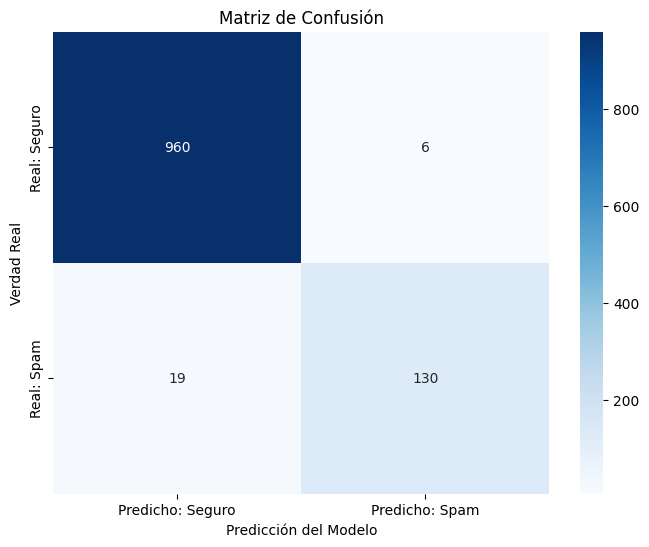


--- Informe de Clasificación ---
              precision    recall  f1-score   support

      Seguro       0.98      0.99      0.99       966
        Spam       0.96      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- Parte A: Generar predicciones masivas ---
# Lógica: Usamos nuestro modelo cargado para predecir TODOS los mensajes
# del set de prueba (X_test) de una sola vez.
# X_test son los mensajes que el modelo NUNCA vio durante el entrenamiento.
print("Realizando predicciones en el conjunto de prueba...")
y_pred = modelo_cargado.predict(X_test)

# --- Parte B: Crear la Matriz de Confusión ---
# Lógica: Comparamos las respuestas correctas (y_test) con las
# respuestas del modelo (y_pred).
matriz = confusion_matrix(y_test, y_pred)

# --- Parte C: Visualizar la Matriz ---
# Lógica: Vamos a dibujar un mapa de calor.
# Eje Y (Vertical): Lo que REALMENTE eran los mensajes.
# Eje X (Horizontal): Lo que el modelo PREDIJO que eran.
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho: Seguro', 'Predicho: Spam'],
            yticklabels=['Real: Seguro', 'Real: Spam'])
plt.title('Matriz de Confusión')
plt.ylabel('Verdad Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# --- Parte D: Informe detallado ---
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=['Seguro', 'Spam']))

# ======================================================================
# FIN DEL CÓDIGO
# ======================================================================
